In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For t-test
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep # For proportion tests

# Set display options for better viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format) # Set float format for cleaner output

print("--- Starting Hypothesis Testing and Experiment Evaluation ---")

# --- Load the Cleaned and Merged DataFrame ---
# Define the path where the processed data is saved
processed_data_path = r'/Users/doarsa/Desktop/IronHack/Projects/Project 005/vanguard-ab-test/data/processed'
input_file_name = 'df_full_ab_test_cleaned.csv'
input_full_path = os.path.join(processed_data_path, input_file_name)

# Load the cleaned and merged DataFrame
try:
    df_full_ab_test = pd.read_csv(input_full_path)
    # Ensure 'date_time' is re-converted to datetime objects after loading from CSV
    df_full_ab_test['date_time'] = pd.to_datetime(df_full_ab_test['date_time'])
    print(f"Successfully loaded df_full_ab_test from: {input_full_path}")

    # Re-apply the specific cleaning for demographic NaNs that was done in the previous notebook
    # This ensures consistency for any demographic-related analyses or statistical tests
    initial_ab_test_rows = len(df_full_ab_test)
    df_full_ab_test.dropna(subset=[
        'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
        'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'
    ], inplace=True)
    print(f"Removed {initial_ab_test_rows - len(df_full_ab_test)} rows with NaNs in demographic columns after reload.")
    print(f"df_full_ab_test now has {len(df_full_ab_test)} entries for analysis.")
    print(f"df_full_ab_test info after loading and cleaning:")
    df_full_ab_test.info()

except FileNotFoundError as e:
    print(f"Error loading file: {e}. Make sure '{input_file_name}' was saved correctly from the previous notebook.")
    exit() # Exit if the file isn't found, as subsequent steps will fail


# --- No need to re-derive KPIs here! They are already in df_full_ab_test ---
# The 'completed_process', 'time_spent_minutes', and 'has_backward_movement' columns
# are now part of df_full_ab_test after being saved and reloaded.
print("\n--- Data Loaded with KPIs Ready for Hypothesis Testing ---")

--- Starting Hypothesis Testing and Experiment Evaluation ---
Successfully loaded df_full_ab_test from: /Users/doarsa/Desktop/IronHack/Projects/Project 005/vanguard-ab-test/data/processed/df_full_ab_test_cleaned.csv
Removed 0 rows with NaNs in demographic columns after reload.
df_full_ab_test now has 302289 entries for analysis.
df_full_ab_test info after loading and cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302289 entries, 0 to 302288
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   client_id              302289 non-null  int64         
 1   visitor_id             302289 non-null  object        
 2   visit_id               302289 non-null  object        
 3   process_step           302289 non-null  object        
 4   date_time              302289 non-null  datetime64[ns]
 5   variation              302289 non-null  object        
 6   clnt_tenure_yr         3

In [ ]:
# Hypothese 1 / Completion Rate

# Significance level (alpha)
alpha = 0.05
print(f"\nUsing a significance level (alpha) of {alpha}")

#### Test 1: Completion Rate (Proportion Z-test) ####
print("\n#### Test 1: Completion Rate (Proportion Z-test) ####")

# Groups data by unique visits (each person’s session).
#For each visit, it checks:
#   Did they complete the process? (max)
#   Average time spent (mean)
#   Did they go backward (error)? (max)

visit_level_kpis = df_full_ab_test.groupby(['client_id', 'visit_id', 'variation']).agg(
    completed_process=('completed_process', 'max'), # Max will be True if any row in the visit was completed
    time_spent_minutes=('time_spent_minutes', 'mean'), # Take mean, will be NaN for non-completed visits
    has_backward_movement=('has_backward_movement', 'max') # Max will be True if any row in the visit had backward movement
).reset_index()


# Counts of completions and total visits for each group
completions_test = visit_level_kpis[(visit_level_kpis['variation'] == 'Test') & (visit_level_kpis['completed_process'] == True)].shape[0]
attempts_test = visit_level_kpis[visit_level_kpis['variation'] == 'Test'].shape[0]

completions_control = visit_level_kpis[(visit_level_kpis['variation'] == 'Control') & (visit_level_kpis['completed_process'] == True)].shape[0]
attempts_control = visit_level_kpis[visit_level_kpis['variation'] == 'Control'].shape[0]

# Handle division by zero if a group has no attempts (though unlikely in real data)
rate_test = completions_test / attempts_test if attempts_test > 0 else 0
rate_control = completions_control / attempts_control if attempts_control > 0 else 0

print(f"Test Group: {int(completions_test)} completions out of {int(attempts_test)} visits. Rate: {rate_test:.4f}")
print(f"Control Group: {int(completions_control)} completions out of {int(attempts_control)} visits. Rate: {rate_control:.4f}")

# Perform z-test for proportions
count = np.array([completions_test, completions_control])
nobs = np.array([attempts_test, attempts_control])

# Null Hypothesis (H0): There is no difference in completion rates between Test and Control.
# Alternative Hypothesis (H1): There is a difference in completion rates. (Two-sided test)
z_stat_completion, p_value_completion = proportions_ztest(count, nobs, alternative='two-sided')

print(f"Z-statistic for Completion Rate: {z_stat_completion:.4f}")
print(f"P-value for Completion Rate: {p_value_completion:.4f}")

# Determine significance
if p_value_completion < alpha:
    print(f"Conclusion: Reject the null hypothesis. The difference in completion rates is statistically significant.")
else:
    print(f"Conclusion: Fail to reject the null hypothesis. The difference in completion rates is NOT statistically significant.")

# Calculate Confidence Interval for the difference in proportions
# Note: confint_proportions_2indep returns (lower, upper) for prop1-prop2
diff_prop = rate_test - rate_control

ci_lower_completion, ci_upper_completion = confint_proportions_2indep(
    completions_test, attempts_test,
    completions_control, attempts_control,
    method='wald', alpha=alpha
)
print(f"Difference in Completion Rates (Test - Control): {diff_prop:.4f}")
print(f"{100*(1-alpha):.0f}% Confidence Interval for Difference: ({ci_lower_completion:.4f}, {ci_upper_completion:.4f})")
if ci_lower_completion > 0:
    print("Interpretation: Test group's completion rate is significantly HIGHER.")
elif ci_upper_completion < 0:
    print("Interpretation: Test group's completion rate is significantly LOWER.")
else:
    print("Interpretation: The confidence interval includes zero, suggesting no significant difference or that the effect is too small to reliably detect.")


Using a significance level (alpha) of 0.05

#### Test 1: Completion Rate (Proportion Z-test) ####
Test Group: 21785 completions out of 37190 visits. Rate: 0.5858
Control Group: 16081 completions out of 32235 visits. Rate: 0.4989
Z-statistic for Completion Rate: 22.9355
P-value for Completion Rate: 0.0000
Conclusion: Reject the null hypothesis. The difference in completion rates is statistically significant.
Difference in Completion Rates (Test - Control): 0.0869
95% Confidence Interval for Difference: (0.0795, 0.0943)
Interpretation: Test group's completion rate is significantly HIGHER.



#### Test 2: Average Time Spent (Independent Samples T-test) ####
Test Group Avg Duration: 6.8895 min (N=17956)
Control Group Avg Duration: 6.6690 min (N=14936)
Std Dev Test: 9.5312, Std Dev Control: 7.5533
Levene's Test P-value: 0.0000
Levene's Test suggests unequal variances. Performing Welch's T-test (equal_var=False).
T-statistic for Average Time Spent: 2.3397
P-value for Average Time Spent: 0.0193
Conclusion: Reject the null hypothesis. The difference in average time spent is statistically significant.


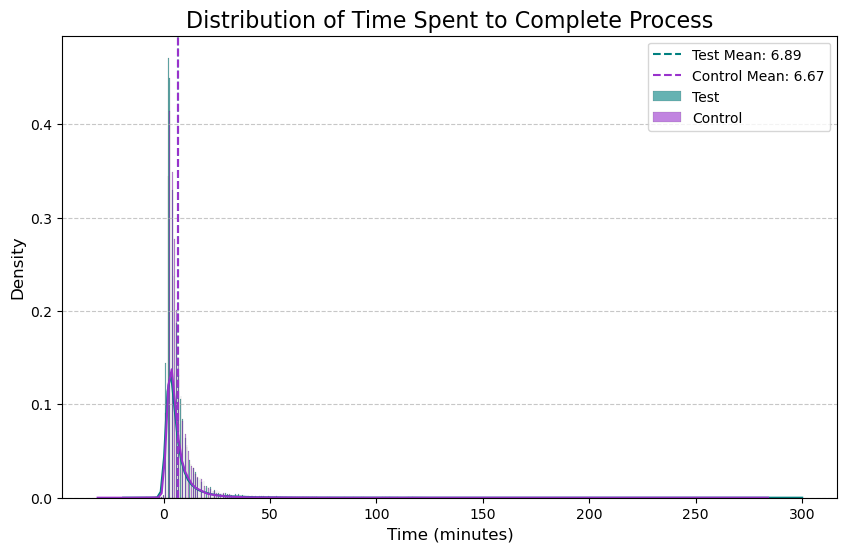

In [22]:
#### Test 2: Average Time Spent to Complete Process (Independent Samples T-test) ####
print("\n#### Test 2: Average Time Spent (Independent Samples T-test) ####")

# Filter for only completed visits that have a time_spent_minutes value
# 'time_spent_minutes' is already NaN for non-completed visits due to the merge in 02_kpi_calculation_analysis.ipynb
test_durations = visit_level_kpis[(visit_level_kpis['variation'] == 'Test') & (visit_level_kpis['completed_process'] == True)]['time_spent_minutes'].dropna()
control_durations = visit_level_kpis[(visit_level_kpis['variation'] == 'Control') & (visit_level_kpis['completed_process'] == True)]['time_spent_minutes'].dropna()

# Ensure both groups have enough data to perform the test
if len(test_durations) < 2 or len(control_durations) < 2:
    print("Not enough completed visits with valid time spent in one or both groups to perform T-test.")
    p_value_time = np.nan # Set p-value to NaN to indicate test not performed
else:
    print(f"Test Group Avg Duration: {test_durations.mean():.4f} min (N={len(test_durations)})")
    print(f"Control Group Avg Duration: {control_durations.mean():.4f} min (N={len(control_durations)})")
    print(f"Std Dev Test: {test_durations.std():.4f}, Std Dev Control: {control_durations.std():.4f}")

    # Check for equal variances (Levene's test)
    # H0: Variances are equal
    # H1: Variances are not equal
    stat_levene, p_value_levene = stats.levene(test_durations, control_durations)
    print(f"Levene's Test P-value: {p_value_levene:.4f}")

    equal_var = True
    if p_value_levene < alpha:
        print("Levene's Test suggests unequal variances. Performing Welch's T-test (equal_var=False).")
        equal_var = False
    else:
        print("Levene's Test suggests equal variances. Performing Student's T-test (equal_var=True).")
        equal_var = True

    # Perform independent samples t-test
    # Null Hypothesis (H0): There is no difference in average time spent between Test and Control.
    # Alternative Hypothesis (H1): There is a difference in average time spent. (Two-sided test)
    t_stat_time, p_value_time = stats.ttest_ind(test_durations, control_durations, equal_var=equal_var, alternative='two-sided')

    print(f"T-statistic for Average Time Spent: {t_stat_time:.4f}")
    print(f"P-value for Average Time Spent: {p_value_time:.4f}")

    if p_value_time < alpha:
        print(f"Conclusion: Reject the null hypothesis. The difference in average time spent is statistically significant.")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis. The difference in average time spent is NOT statistically significant.")

    # Visualize the distributions
    plt.figure(figsize=(10, 6))
    sns.histplot(test_durations, kde=True, color='teal', label='Test', stat='density', alpha=0.6)
    sns.histplot(control_durations, kde=True, color='darkorchid', label='Control', stat='density', alpha=0.6)
    plt.axvline(test_durations.mean(), color='teal', linestyle='dashed', linewidth=1.5, label=f'Test Mean: {test_durations.mean():.2f}')
    plt.axvline(control_durations.mean(), color='darkorchid', linestyle='dashed', linewidth=1.5, label=f'Control Mean: {control_durations.mean():.2f}')
    plt.title('Distribution of Time Spent to Complete Process', fontsize=16)
    plt.xlabel('Time (minutes)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [23]:
#### Test 3: Error Rate (Proportion Z-test) ####
print("\n#### Test 3: Error Rate (Proportion Z-test) ####")

# Counts of visits with backward movement and total visits for each group
errors_test = visit_level_kpis[(visit_level_kpis['variation'] == 'Test') & (visit_level_kpis['has_backward_movement'] == True)].shape[0]
total_visits_test = visit_level_kpis[visit_level_kpis['variation'] == 'Test'].shape[0]

errors_control = visit_level_kpis[(visit_level_kpis['variation'] == 'Control') & (visit_level_kpis['has_backward_movement'] == True)].shape[0]
total_visits_control = visit_level_kpis[visit_level_kpis['variation'] == 'Control'].shape[0]

# Handle division by zero if a group has no total visits
prop_error_test = errors_test / total_visits_test if total_visits_test > 0 else 0
prop_error_control = errors_control / total_visits_control if total_visits_control > 0 else 0


print(f"Test Group: {int(errors_test)} visits with errors out of {int(total_visits_test)} visits. Rate: {prop_error_test:.4f}")
print(f"Control Group: {int(errors_control)} visits with errors out of {int(total_visits_control)} visits. Rate: {prop_error_control:.4f}")

# Perform z-test for proportions
count_errors = np.array([errors_test, errors_control])
nobs_errors = np.array([total_visits_test, total_visits_control])

# Null Hypothesis (H0): There is no difference in error rates between Test and Control.
# Alternative Hypothesis (H1): There is a difference in error rates. (Two-sided test)
z_stat_error, p_value_error = proportions_ztest(count_errors, nobs_errors, alternative='two-sided')

print(f"Z-statistic for Error Rate: {z_stat_error:.4f}")
print(f"P-value for Error Rate: {p_value_error:.4f}")

# Determine significance
if p_value_error < alpha:
    print(f"Conclusion: Reject the null hypothesis. The difference in error rates is statistically significant.")
else:
    print(f"Conclusion: Fail to reject the null hypothesis. The difference in error rates is NOT statistically significant.")

# Calculate Confidence Interval for the difference in proportions
diff_prop_error = prop_error_test - prop_error_control

ci_lower_error, ci_upper_error = confint_proportions_2indep(
    errors_test, total_visits_test,
    errors_control, total_visits_control,
    method='wald', alpha=alpha
)
print(f"Difference in Error Rates (Test - Control): {diff_prop_error:.4f}")
print(f"{100*(1-alpha):.0f}% Confidence Interval for Difference: ({ci_lower_error:.4f}, {ci_upper_error:.4f})")
if ci_lower_error > 0:
    print("Interpretation: Test group's error rate is significantly HIGHER.")
elif ci_upper_error < 0:
    print("Interpretation: Test group's error rate is significantly LOWER.")
else:
    print("Interpretation: The confidence interval includes zero, suggesting no significant difference or that the effect is too small to reliably detect.")


### --- Experiment Evaluation and Recommendation ---
print("\n--- Experiment Evaluation and Recommendation ---")

print("\n**Summary of Hypothesis Test Results:**")
# Handle potential NaN p-values if a test couldn't be performed (e.g., due to insufficient data after NaN removal)
p_value_completion_display = f"{p_value_completion:.4f}" if not pd.isna(p_value_completion) else "N/A"
# For p_value_time, ensure it's defined before trying to format
p_value_time_display = f"{p_value_time:.4f}" if 'p_value_time' in locals() and not pd.isna(p_value_time) else "N/A (Not enough data)"
p_value_error_display = f"{p_value_error:.4f}" if not pd.isna(p_value_error) else "N/A"

is_significant_completion = p_value_completion < alpha if not pd.isna(p_value_completion) else False
is_significant_time = 'p_value_time' in locals() and p_value_time < alpha if not pd.isna(p_value_time) else False
is_significant_error = p_value_error < alpha if not pd.isna(p_value_error) else False

# Recalculate means for the final summary to ensure they are available even if test not performed
mean_test_duration_summary = test_durations.mean() if 'test_durations' in locals() and not test_durations.empty else np.nan
mean_control_duration_summary = control_durations.mean() if 'control_durations' in locals() and not control_durations.empty else np.nan

print(f"Completion Rate: P-value = {p_value_completion_display} (Statistically Significant: {is_significant_completion})")
print(f"Average Time Spent: P-value = {p_value_time_display} (Statistically Significant: {is_significant_time})")
print(f"Error Rate: P-value = {p_value_error_display} (Statistically Significant: {is_significant_error})")

print("\n**Overall Recommendation:**")

overall_recommendation = ""
recommendation_details = []

# Analyze Completion Rate
if is_significant_completion and diff_prop > 0:
    recommendation_details.append(f"- **Positive:** The Test group has a statistically significant higher completion rate ({rate_test*100:.2f}%) compared to the Control group ({rate_control*100:.2f}%). This indicates better user flow through the process.")
else:
    recommendation_details.append(f"- **Neutral/Negative:** No significant improvement or even a decrease in completion rate for the Test group (Test: {rate_test*100:.2f}%, Control: {rate_control*100:.2f}%).")

# Analyze Average Time Spent
if not is_significant_time:
    recommendation_details.append(f"- **Neutral:** No statistically significant difference in average time spent (Test: {mean_test_duration_summary:.2f} min, Control: {mean_control_duration_summary:.2f} min).")
elif mean_test_duration_summary < mean_control_duration_summary:
    recommendation_details.append(f"- **Positive:** The Test group statistically significantly reduces the average time spent ({mean_test_duration_summary:.2f} min) compared to Control ({mean_control_duration_summary:.2f} min).")
else: # mean_test_duration_summary > mean_control_duration_summary
    recommendation_details.append(f"- **Negative:** The Test group statistically significantly increases the average time spent ({mean_test_duration_summary:.2f} min) compared to Control ({mean_control_duration_summary:.2f} min). This suggests the new process might be slower or more complex.")


# Analyze Error Rate (Backward Movement)
if is_significant_error:
    if diff_prop_error < 0: # Test error rate is lower than Control
        recommendation_details.append(f"- **Positive:** The Test group statistically significantly reduces the error rate ({prop_error_test*100:.2f}%) compared to Control ({prop_error_control*100:.2f}%).")
    else: # Test error rate is higher than Control
        recommendation_details.append(f"- **Negative:** The Test group statistically significantly increases the error rate ({prop_error_test*100:.2f}%) compared to Control ({prop_error_control*100:.2f}%). This indicates more user confusion or navigation issues.")
else:
    recommendation_details.append(f"- **Neutral:** No statistically significant difference in error rate (Test: {prop_error_test*100:.2f}%, Control: {prop_error_control*100:.2f}%).")


# Formulate the overall recommendation based on corrected logic for NaNs
# Check if tests actually yielded significant results and in the desired direction
sig_comp_pos = is_significant_completion and diff_prop > 0
sig_time_pos = is_significant_time and mean_test_duration_summary < mean_control_duration_summary if not pd.isna(mean_test_duration_summary) and not pd.isna(mean_control_duration_summary) else False
sig_error_pos = is_significant_error and diff_prop_error < 0 # lower error rate is positive

sig_time_neg = is_significant_time and mean_test_duration_summary > mean_control_duration_summary if not pd.isna(mean_test_duration_summary) and not pd.isna(mean_control_duration_summary) else False
sig_error_neg = is_significant_error and diff_prop_error > 0 # higher error rate is negative


if sig_comp_pos and not sig_time_neg and not sig_error_neg:
    overall_recommendation = "Based on the analysis, the new design (Test group) shows a statistically significant improvement in completion rate, and either no significant negative impact or even positive impacts on time spent and error rate. Therefore, it is **recommended to launch the new design**."
elif sig_comp_pos and (sig_time_neg or sig_error_neg):
    overall_recommendation = "The new design (Test group) significantly improves completion rate, but also introduces statistically significant negative impacts on time spent or error rate. This presents a trade-off. **Further investigation is needed** to understand the root causes of increased time and errors, or to find a way to mitigate these negative impacts while retaining the higher completion rate. A partial rollout or A/B testing of specific components might be considered."
else:
    overall_recommendation = "The new design (Test group) does not consistently show a clear, overall positive impact across all key metrics, or it introduces significant negative trade-offs. It is **recommended NOT to launch the new design as is**. Further iteration on the design is required to address the identified issues and re-test."


print(overall_recommendation)
print("\nRecommendation Details:")
for detail in recommendation_details:
    print(detail)

print("\n--- Hypothesis Testing and Evaluation Complete ---")


#### Test 3: Error Rate (Proportion Z-test) ####
Test Group: 25785 visits with errors out of 37190 visits. Rate: 0.6933
Control Group: 20178 visits with errors out of 32235 visits. Rate: 0.6260
Z-statistic for Error Rate: 18.7150
P-value for Error Rate: 0.0000
Conclusion: Reject the null hypothesis. The difference in error rates is statistically significant.
Difference in Error Rates (Test - Control): 0.0674
95% Confidence Interval for Difference: (0.0603, 0.0744)
Interpretation: Test group's error rate is significantly HIGHER.

--- Experiment Evaluation and Recommendation ---

**Summary of Hypothesis Test Results:**
Completion Rate: P-value = 0.0000 (Statistically Significant: True)
Average Time Spent: P-value = 0.0193 (Statistically Significant: True)
Error Rate: P-value = 0.0000 (Statistically Significant: True)

**Overall Recommendation:**
The new design (Test group) significantly improves completion rate, but also introduces statistically significant negative impacts on time spen

In [25]:
# Hypothesis no 2 / Testing Completion Rate with a Cost-Effectiveness Threshold

# --- Helper Function for Process Step Order ---
process_step_order = {
    'start': 0,
    'step_1': 1,
    'step_2': 2,
    'step_3': 3,
    'confirm': 4
}
# Map the 'process_step' column to its numerical order
df_full_ab_test['step_order'] = df_full_ab_test['process_step'].map(process_step_order)


## Completion Rate 

# Find the maximum step order for each client and visit
max_steps_per_visit = df_full_ab_test.groupby(['client_id', 'visit_id', 'variation'])['step_order'].max().reset_index()
max_steps_per_visit.rename(columns={'step_order': 'max_step_order'}, inplace=True)

# Determine if a visit resulted in completion (reached 'confirm' step, which is order 4)
# Renamed to 'completed_process' to match previous discussions and avoid potential conflicts
max_steps_per_visit['completed_process_x'] = (max_steps_per_visit['max_step_order'] == 4)


# Calculate completion rate per variation using the 'max_steps_per_visit' (which is aggregated per visit)
# We use max_steps_per_visit here for the rate calculation as it represents unique visits
completion_rates = max_steps_per_visit.groupby('variation')['completed_process_x'].value_counts(normalize=True).unstack(fill_value=0)


# If 'True' and 'False' columns exist, pick 'True' which means completion
if True in completion_rates.columns:
    completion_rates_final = completion_rates[True] * 100
else: # Case where a group might have 0 completions
    completion_rates_final = pd.Series(0.0, index=completion_rates.index) # Initialize with 0% if no completions

#print("Completion Rates per Variation:")
#print(completion_rates_final)

# Count of completions and total visits per variation
group_counts = max_steps_per_visit.groupby('variation')['completed_process_x'].agg(['sum', 'count'])
group_counts.rename(columns={'sum': 'completions', 'count': 'total_visits'}, inplace=True)
#print("\nCompletion Counts and Total Visits per Variation:")
#print(group_counts)

import numpy as np
from scipy.stats import norm

# Extract values
x1 = group_counts.loc['Control', 'completions']
n1 = group_counts.loc['Control', 'total_visits']
x2 = group_counts.loc['Test', 'completions']
n2 = group_counts.loc['Test', 'total_visits']

# Proportions
p1 = x1 / n1  # Control
p2 = x2 / n2  # Test

# Standard Error
se = np.sqrt((p1 * (1 - p1)) / n1 + (p2 * (1 - p2)) / n2)

# Threshold for cost-effectiveness
delta = 0.05  # 5% absolute increase

# Z-score adjusted for the threshold
z = (p2 - (p1 + delta)) / se

# One-sided p-value
p_value = 1 - norm.cdf(z)

# Print results
print(f"\n--- Hypothesis Test Results ---")
print(f"Control Completion Rate: {p1:.4f}")
print(f"Test Completion Rate: {p2:.4f}")
print(f"Z-Score: {z:.4f}")
print(f"P-Value (one-sided): {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The Test group exceeds the Control group by more than 5%.")
else:
    print("Fail to reject the null: The Test group does NOT significantly exceed the Control group by more than 5%.")



--- Hypothesis Test Results ---
Control Completion Rate: 0.4989
Test Completion Rate: 0.5858
Z-Score: 9.7669
P-Value (one-sided): 0.0000
Reject the null hypothesis: The Test group exceeds the Control group by more than 5%.


In [ ]:
# Hypothesis that are suggested 01: "Is a client’s gender associated with their likelihood to complete the process, depending on whether they’re in the Control or Test group?"

import pandas as pd
from scipy.stats import chi2_contingency

# Make a contingency table for just the Test group
test_group = df_full_ab_test[df_full_ab_test['variation'] == 'Test']

# Drop NaNs or unknowns if needed
test_group_clean = test_group[test_group['gendr'].isin(['Male', 'Female', 'Unknown'])]

# Create a contingency table
ct_test = pd.crosstab(test_group_clean['gendr'], test_group_clean['completed_process'])

# Run Chi-square test
chi2, p, dof, expected = chi2_contingency(ct_test)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)


Chi-square statistic: 288.29843766229834
Degrees of freedom: 2
P-value: 2.4933870008101153e-63


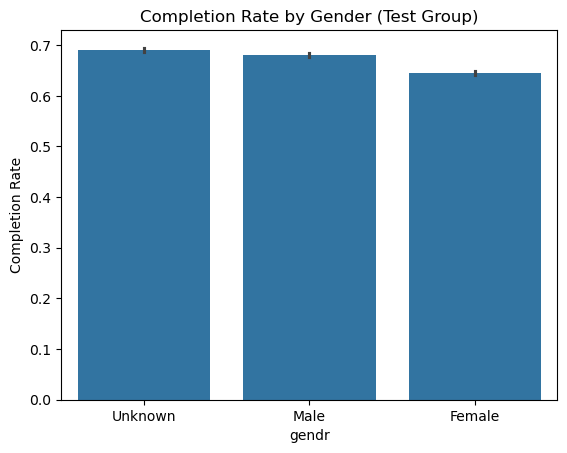

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=test_group_clean, x='gendr', y='completed_process')
plt.title("Completion Rate by Gender (Test Group)")
plt.ylabel("Completion Rate")
plt.show()

# p-value is practically zero (way below 0.05), which means:
# We reject the null hypothesis.
#There's strong evidence of a relationship between gender and completion rate in the Test group (but that is not totally accurate since the biggest percentage is Unkown).

In [ ]:
#Hypothesis that are suggested 02

# If the average client tenure (how long they've been with Vanguard) of those engaging with the new process is the same as those engaging with the old process

df_completed = df_full_ab_test[df_full_ab_test['completed_process'] == True]

# Group average tenure
mean_tenure = df_completed.groupby('variation')['clnt_tenure_yr'].mean()
print(mean_tenure)


# Two-Sample t-test
from scipy.stats import ttest_ind

# Extract tenure for each group
tenure_control = df_completed[df_completed['variation'] == 'Control']['clnt_tenure_yr']
tenure_test = df_completed[df_completed['variation'] == 'Test']['clnt_tenure_yr']

# Run the t-test
t_stat, p_value = ttest_ind(tenure_control, tenure_test, equal_var=False)  # Welch's t-test

print("T-statistic:", t_stat)
print("P-value:", p_value)


# This means the difference in average tenure between the Test and Control groups is not statistically significant.
# We fail to reject the null hypothesis.
# There's no evidence that client tenure is related to whether a client completed the process under the new or old design.

# A two-sample t-test was conducted to compare the average client tenure between those who completed the process in the Control and Test groups.
# The average tenure was nearly identical (Control: 12.06 years, Test: 12.04 years), and the difference was not statistically significant (t = 0.73, p = 0.468).
# This suggests that client tenure did not influence process completion across design variations.





variation
Control   12.0627
Test      12.0403
Name: clnt_tenure_yr, dtype: float64
T-statistic: 0.7257606202026953
P-value: 0.46798641768984395


In [ ]:
# Hypothesis that are suggested 03
# Is the average age of clients who completed the process differs between the Control (old process) and Test (new process) groups.

# filter only completed clients
df_completed = df_full_ab_test[df_full_ab_test['completed_process'] == True]

#average age per variation
mean_age = df_completed.groupby('variation')['clnt_age'].mean()
print(mean_age)

# run the Two-Sample t-Test

from scipy.stats import ttest_ind

# Separate the two groups
age_control = df_completed[df_completed['variation'] == 'Control']['clnt_age']
age_test = df_completed[df_completed['variation'] == 'Test']['clnt_age']

# Run the Welch's t-test (assumes unequal variances)
t_stat, p_value = ttest_ind(age_control, age_test, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)


#This p-value is much greater than 0.05, which means:
#we fail to reject the null hypothesis.
#There's no statistically significant difference in the average age of clients between the Control and Test groups.


#A Welch’s two-sample t-test was conducted to compare the average age of clients who completed the process in the Control and Test groups.
#The average ages were nearly identical (Control: 47.09 years, Test: 47.10 years), and the difference was not statistically significant (t = -0.18, p = 0.854).
#This suggests that client age did not influence completion behavior between the old and new interface designs.

variation
Control   47.0866
Test      47.0993
Name: clnt_age, dtype: float64
T-statistic: -0.18436521772772255
P-value: 0.8537271478747499


In [35]:
# Experiment Evaluation

# 1. Was the experiment well-structured?

# A/B test structure 
# Clear goal: improve completion rate 
# Control and Test groups defined 

# 2.Were clients randomly and equally divided between the old and new designs?

# Use one row per client or per visit, depending on your unit of assignment
client_split = df_full_ab_test[['client_id', 'variation']].drop_duplicates()

# Count number of clients per variation
print(client_split['variation'].value_counts(normalize=True))

variation
Test      0.5340
Control   0.4660
Name: proportion, dtype: float64


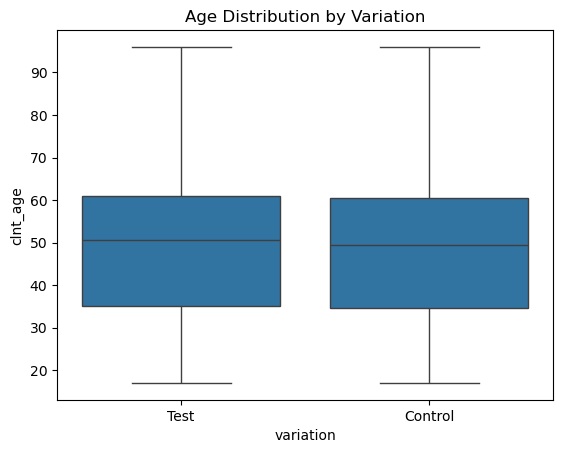

gendr      Female   Male  Unknown      X
variation                               
Control    0.3175 0.3385   0.3440    NaN
Test       0.3294 0.3357   0.3348 0.0000


In [ ]:
# 3.Were there any biases?
# We are going to check for biases in demographics between groups: Compare age or gender between Control and Test.

import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for age
sns.boxplot(x='variation', y='clnt_age', data=df_full_ab_test)
plt.title("Age Distribution by Variation")
plt.show()

# Or check gender balance
print(df_full_ab_test.groupby('variation')['gendr'].value_counts(normalize=True).unstack())


# Very Similar Distribution / the percentages across Female, Male, and Unknown are very close (within ~1%).
# Age distribution is very similar across Test and Contril group. 

Earliest date: 2017-03-15 00:19:00
Latest date: 2017-06-20 23:57:00


<Axes: title={'center': 'Weekly Visit Volume'}, xlabel='week'>

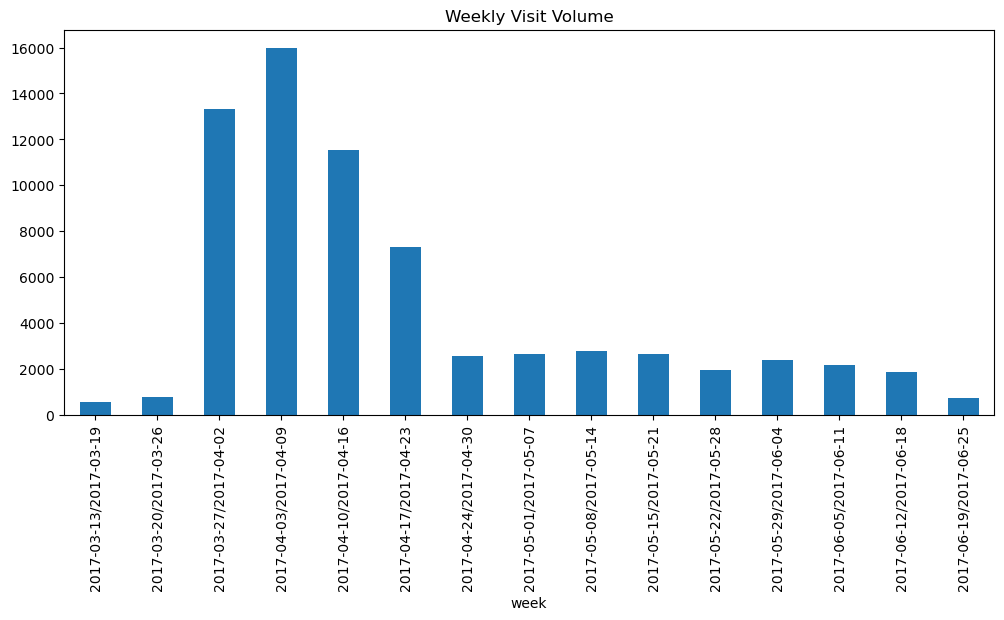

In [ ]:
# Duration Assessment

df_full_ab_test['date_time'] = pd.to_datetime(df_full_ab_test['date_time'])

print("Earliest date:", df_full_ab_test['date_time'].min())
print("Latest date:", df_full_ab_test['date_time'].max())

df_full_ab_test['week'] = df_full_ab_test['date_time'].dt.to_period('W').astype(str)
weekly_visits = df_full_ab_test.groupby('week')['visit_id'].nunique()

weekly_visits.plot(kind='bar', figsize=(12, 5), title='Weekly Visit Volume')


#The experiment ran for ~3 months, which is generally enough time, but:
#Activity was not consistent over time: there are spikes during month of April.

In [ ]:
# Additional Data Needed:
# Device type (mobile vs. desktop)/completion rates might differ on mobile.
# Customer satisfaction score 